In [1]:
import importlib
import numpy as np
import polars as pl
import scipy.sparse as sp
import torch
import torch.nn as nn
from tqdm import tqdm

from datasets import DATA_FOLDER, Dataloader, prepare_interaction_data, split_input_target_interactions
from util import CHECKPOINT_FOLDER, get_checkpoint_filepath, load_checkpoint, load_config_from_checkpoint, set_seed

# device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.mps.is_available() else torch.device("cpu")
device = torch.device("cuda:3")

DATASET = "ML-25M"
# SAE_CHECKPOINT_PATH = f"{CHECKPOINT_FOLDER}/{DATASET}/TopKSAE-8192-3c29e9ee.ckpt"  # ELSA + Cosine
SAE_CHECKPOINT_PATH = f"{CHECKPOINT_FOLDER}/{DATASET}/TopKSAE-8192-d6337b64.ckpt"  # ELSA + L2
# SAE_CHECKPOINT_PATH = f"{CHECKPOINT_FOLDER}/{DATASET}/TopKSAE-8192-f634db83.ckpt"  # MultVAE + L2

sae_cfg = load_config_from_checkpoint(SAE_CHECKPOINT_PATH)
cf_checkpoint_path = f"{CHECKPOINT_FOLDER}/{DATASET}/{sae_cfg['pretrained_model_checkpoint']}"
cf_model_cfg = load_config_from_checkpoint(cf_checkpoint_path)

set_seed(sae_cfg["seed"])

interactions_df, train_csr, val_csr, test_csr, train_users, val_users, test_users, items = prepare_interaction_data(cf_model_cfg)
train_users_to_idxs = {uid: uidx for uidx, uid in enumerate(train_users)}
val_users_to_idxs = {uid: uidx for uidx, uid in enumerate(val_users)}
test_users_to_idxs = {uid: uidx for uidx, uid in enumerate(test_users)}
items_to_idxs = {iid: iidx for iidx, iid in enumerate(items)}

items_df = (
    pl.scan_csv(f"{DATA_FOLDER}/{DATASET}/movies.csv").rename({"movieId": "item_id"}).cast({"item_id": pl.String}).cast({"item_id": pl.Categorical}).collect()
)

cf_model_class = getattr(importlib.import_module(cf_model_cfg["model_module"]), cf_model_cfg["model_class"])
if cf_model_cfg["model_class"] == "ELSA":
    cf_model = cf_model_class(train_csr.shape[1], cf_model_cfg["embedding_dim"]).to(device)
elif cf_model_cfg["model_class"] == "MultVAE":
    cf_model = cf_model_class(
        train_csr.shape[1],
        [int(x) for x in cf_model_cfg["hidden_dims"].split(",") if x.strip()],
        cf_model_cfg["embedding_dim"],
        cf_model_cfg["annealing_beta"],
        cf_model_cfg["annealing_steps"],
    ).to(device)
_, _ = load_checkpoint(cf_model, None, get_checkpoint_filepath(cf_model_cfg), device, None)

sae_model_class = getattr(importlib.import_module(sae_cfg["model_module"]), sae_cfg["model_class"])
sae_extra_params = {k: sae_cfg[k] for k in sae_cfg.keys() if k in ["l1_coef", "k"]}
sae = sae_model_class(cf_model_cfg["embedding_dim"], sae_cfg["embedding_dim"], sae_cfg["reconstruction_loss"], l1_coef=sae_cfg["l1_coef"], k=sae_cfg["k"]).to(
    device
)
_, _ = load_checkpoint(sae, None, get_checkpoint_filepath(sae_cfg), device, None)

test_inputs, test_targets = split_input_target_interactions(test_csr, cf_model_cfg["target_interaction_ratio"])

Removing users with < 5 interactions...
Dataset info: users=160776, items=40857, interactions=12448242
Train split info: users=128621, items=40857, interactions=9969436
Val split info: users=16078, items=40857, interactions=1221296
Test split info: users=16077, items=40857, interactions=1257510
Loaded checkpoint from checkpoints/ML-25M/ELSA-1024-10977915.ckpt (after 13 epochs)
Loaded checkpoint from checkpoints/ML-25M/TopKSAE-8192-d6337b64.ckpt (after 761 epochs)


In [2]:
sparse_item_embeddings = []
onehot_items_dataloader = Dataloader(sp.eye(len(items), dtype=np.float32, format="csr"), batch_size=1024, device=device)
with torch.no_grad():
    for onehot_batch in tqdm(onehot_items_dataloader):
        user_embedding = cf_model.encode(onehot_batch)  # Tensor, shape = (batch.shape[0] x elsa_cfg["embedding_dim"])
        if cf_model_cfg["model_class"] != "ELSA":
            user_embedding = user_embedding[0]
        sae_embedding, _, input_mean, input_std = sae.encode(user_embedding)
        sparse_item_embeddings.append(sp.csr_matrix(sae_embedding.cpu().numpy()))
sparse_item_embeddings = sp.vstack(sparse_item_embeddings)

neuron_is_alive = np.asarray(sparse_item_embeddings.sum(axis=0)).flatten() != 0
living_neurons = np.where(neuron_is_alive)[0]
dead_neuron_count = sparse_item_embeddings.shape[1] - neuron_is_alive.sum()
print(f"{dead_neuron_count} dead neurons out of {sparse_item_embeddings.shape[1]} ({dead_neuron_count / sparse_item_embeddings.shape[1]:.2%})")
print(f"{neuron_is_alive.sum()} alive ones")

100%|██████████| 40/40 [00:06<00:00,  6.56it/s]

4267 dead neurons out of 8192 (52.09%)
3925 alive ones


In [3]:
tag_df = (
    pl.scan_csv(f"{DATA_FOLDER}/{DATASET}/tags.csv")
    .rename({"userId": "user_id", "movieId": "item_id"})
    .cast({"user_id": pl.String, "item_id": pl.String})
    .cast({"user_id": pl.Categorical, "item_id": pl.Categorical})
    .with_columns(pl.col("tag").str.to_lowercase().str.strip_chars().alias("tag"))  # convert to lowercase and strip whitespace
    .filter(pl.col("tag").count().over("tag") >= 100)  # keep only tags assigned at least 100 times
    .filter(pl.col("item_id").is_in(items))  # keep only items with interactions
    .with_columns(pl.col("item_id").replace_strict(items_to_idxs).alias("item_idx"))
    .cast({"tag": pl.Categorical})
    .collect()
)

tag_df

sys:1: CategoricalRemappingWarning: Local categoricals have different encodings, expensive re-encoding is done to perform this merge operation. Consider using a StringCache or an Enum type if the categories are known in advance


user_id,item_id,tag,timestamp,item_idx
cat,cat,cat,i64,i64
"""3""","""260""","""classic""",1439472355,43
"""3""","""260""","""sci-fi""",1439472256,43
"""4""","""1732""","""dark comedy""",1573943598,181
"""4""","""1732""","""great dialogue""",1573943604,181
"""4""","""7569""","""so bad it's good""",1573943455,5010
…,…,…,…,…
"""162462""","""260""","""space""",1427470029,43
"""162492""","""260""","""classic sci-fi""",1436468895,43
"""162492""","""260""","""epic""",1436468882,43


In [4]:
def get_tag_item_counts(tag_df: pl.DataFrame, user_subset: np.ndarray | None = None) -> tuple[np.ndarray, sp.csr_matrix]:
    tags = tag_df["tag"].unique(maintain_order=True).to_numpy()
    num_tags = tag_df["tag"].n_unique()
    num_items = len(items)
    if user_subset is not None:
        tag_df = tag_df.filter(pl.col("user_id").is_in(user_subset))
    tag_item_counts = sp.csr_matrix(
        (
            np.ones(len(tag_df), dtype=np.float32),
            (tag_df["tag"].to_physical().to_numpy(), tag_df["item_idx"].to_numpy()),
        ),
        shape=(num_tags, num_items),
    )
    return tags, tag_item_counts


tags, train_tag_item_counts = get_tag_item_counts(tag_df, user_subset=train_users)

tags, train_tag_item_counts

(array(['classic', 'sci-fi', 'dark comedy', ..., '05/11', '06/11', 'tivo'],
       dtype=object),
 <Compressed Sparse Row sparse matrix of dtype 'float32'
 	with 134271 stored elements and shape (1633, 40857)>)

In [5]:
from abc import ABC, abstractmethod
from typing import Any

from elsa import ELSA
from sae import SAE


class SteeredModel(ABC):
    def __init__(self, base_model):
        self.base_model = base_model

    def eval(self):
        self.base_model.eval()

    @abstractmethod
    def recommend(self, batch: Any, k: int, mask_interactions: bool = True) -> tuple[torch.Tensor, torch.Tensor]:
        raise NotImplementedError


class SAESteeredELSA(SteeredModel):
    def __init__(self, base_model: ELSA, sae: SAE, concept_neuron_mapping: torch.Tensor, alpha: float):
        self.base_model = base_model
        self.sae = sae
        self.concept_neuron_mapping = concept_neuron_mapping
        self.alpha = alpha  # steering strength

    @torch.no_grad()
    def encode(self, interaction_batch: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        user_embeddings = self.base_model.encode(interaction_batch)
        sae_embeddings, _, input_mean, input_std = self.sae.encode(user_embeddings)
        return sae_embeddings, input_mean, input_std

    @torch.no_grad()
    def decode(self, sae_embeddings: torch.Tensor, input_mean: torch.Tensor, input_std: torch.Tensor) -> torch.Tensor:
        return self.base_model.decode(self.sae.decode(sae_embeddings, input_mean, input_std))

    @torch.no_grad()
    def recommend(self, batch: tuple[torch.Tensor, torch.Tensor], k: int, mask_interactions: bool = True) -> tuple[torch.Tensor, torch.Tensor]:
        interaction_batch, steering_concept_id_batch = batch

        sae_embeddings, input_mean, input_std = self.encode(interaction_batch)
        neuron_batch = self.concept_neuron_mapping[steering_concept_id_batch]
        s = sae_embeddings.sum(-1, keepdim=True)
        sae_embeddings *= (1 - self.alpha) / s
        sae_embeddings[torch.arange(neuron_batch.shape[0]), neuron_batch] += self.alpha
        sae_embeddings *= s
        scores = nn.ReLU()(self.decode(sae_embeddings, input_mean, input_std) - interaction_batch)

        if mask_interactions:
            scores = torch.where(interaction_batch != 0, 0, scores)  # mask input interactions
        topk_scores, topk_indices = torch.topk(scores, k)
        return topk_scores.cpu().numpy(), topk_indices.cpu().numpy()


class SegmentBoosting(SteeredModel):
    def __init__(self, base_model, concept_items: sp.csr_matrix, alpha: float):
        self.base_model = base_model
        self.concept_items = concept_items
        self.alpha = alpha  # steering strength

    @torch.no_grad()
    def recommend(self, batch: tuple[torch.Tensor, torch.Tensor], k: int, mask_interactions: bool = True) -> tuple[torch.Tensor, torch.Tensor]:
        interaction_batch, steering_concept_id_batch = batch
        base_model_scores = self.base_model(interaction_batch)
        batch_concept_items = self.concept_items[steering_concept_id_batch.cpu().numpy()]
        scores = (1 - self.alpha) * base_model_scores + self.alpha * torch.tensor(
            batch_concept_items.toarray(), device=base_model_scores.device, dtype=base_model_scores.dtype
        )
        if mask_interactions:
            scores = torch.where(interaction_batch != 0, 0, scores)  # mask input interactions
        topk_scores, topk_indices = torch.topk(scores, k)
        return topk_scores.cpu().numpy(), topk_indices.cpu().numpy()

In [6]:
def compute_tfidf(X):
    """
    Compute TF-IDF for a term-document value matrix.
    Parameters:
    X: np.ndarray (num_terms, num_documents)
    Returns:
    tfidf_matrix: np.ndarray (num_terms, num_documents) - TF-IDF values
    """
    # Compute Term Frequency (TF) - Normalize by column sum
    tf = X / np.sum(X, axis=0, keepdims=True)
    tf[np.isnan(tf)] = 0  # Handle division by zero
    # Compute Document Frequency (DF) - Count nonzero occurrences of each term
    df = np.count_nonzero(X, axis=1)
    # Compute Inverse Document Frequency (IDF) - Log-scaled
    num_documents = X.shape[1]
    idf = np.log((num_documents + 1) / (df + 1)) + 1  # Smoothing
    # Compute TF-IDF
    tfidf_matrix = tf * idf[:, np.newaxis]
    return tfidf_matrix


train_tag_to_idx = {t: i for i, t in enumerate(tags)}

pti = train_tag_item_counts.copy()
pti.data /= pti.data.sum()
tag_neuron_activity = pti @ sparse_item_embeddings  # tag x neuron (CSR matrix)

# neuron -> tag that elicits most distinctive response in this neuron
top_tag_per_neuron = tags[compute_tfidf(tag_neuron_activity.toarray().T).argmax(axis=1)]  # term = neuron, document = tag
top_tag_per_neuron[~neuron_is_alive] = None

# neuron -> tag that best characterizes the neuron's overall activity
characteristic_tag_per_neuron = tags[compute_tfidf(tag_neuron_activity.toarray()).argmax(axis=0)]  # term = tag, document = neuron
characteristic_tag_per_neuron[~neuron_is_alive] = None

# tag -> neuron that most representatively encodes this tag
characteristic_neuron_per_tag = compute_tfidf(tag_neuron_activity.toarray().T).argmax(axis=0)  # term = neuron, document = tag

# tag -> neuron whose firing is most unique to that tag
top_neuron_per_tag = compute_tfidf(tag_neuron_activity.toarray()).argmax(axis=1)  # term = neuron, document = tag

print(pl.Series("top_neuron", top_neuron_per_tag).value_counts(sort=True))
print(pl.Series("top_tag", top_tag_per_neuron[neuron_is_alive]).value_counts(sort=True))


tags, characteristic_neuron_per_tag

/tmp/ipykernel_284872/1480804396.py:10: RuntimeWarning: invalid value encountered in divide
  tf = X / np.sum(X, axis=0, keepdims=True)


shape: (888, 2)
┌────────────┬───────┐
│ top_neuron ┆ count │
│ ---        ┆ ---   │
│ i64        ┆ u32   │
╞════════════╪═══════╡
│ 571        ┆ 10    │
│ 4529       ┆ 6     │
│ 8069       ┆ 6     │
│ 6535       ┆ 6     │
│ 1782       ┆ 6     │
│ …          ┆ …     │
│ 1304       ┆ 1     │
│ 6780       ┆ 1     │
│ 5014       ┆ 1     │
│ 1854       ┆ 1     │
│ 2786       ┆ 1     │
└────────────┴───────┘
shape: (971, 2)
┌──────────────────┬───────┐
│ top_tag          ┆ count │
│ ---              ┆ ---   │
│ str              ┆ u32   │
╞══════════════════╪═══════╡
│ classic          ┆ 42    │
│ pre-code         ┆ 18    │
│ aardman          ┆ 17    │
│ silent film      ┆ 16    │
│ woody allen      ┆ 16    │
│ …                ┆ …     │
│ darren aronofsky ┆ 1     │
│ treasure         ┆ 1     │
│ ewan mcgregor    ┆ 1     │
│ blindness        ┆ 1     │
│ sexy             ┆ 1     │
└──────────────────┴───────┘


(array(['classic', 'sci-fi', 'dark comedy', ..., '05/11', '06/11', 'tivo'],
       dtype=object),
 array([4447, 4447, 1341, ...,  305, 1301,    0]))

In [21]:
from util import evaluate_ndcg_at_k, evaluate_recall_at_k


def evaluate_steering(model, inputs: sp.csr_matrix, targets: sp.csr_matrix, tag_df: pl.DataFrame, cfg: dict, device: torch.device) -> dict:
    tags, tag_item_counts = get_tag_item_counts(tag_df)
    tag_item_counts.data[:] = 1  # binarize  TODO maybe we need more than 1 assignment?
    item_tag_counts = tag_item_counts.T.astype(np.int64).toarray()
    input_tags_per_user = inputs.astype(np.int64) @ item_tag_counts
    target_tags_per_user = targets.astype(np.int64) @ item_tag_counts
    desired_tags_per_user = target_tags_per_user - input_tags_per_user  # TODO filter out tags from inputs
    desired_tags_per_user[desired_tags_per_user < 0] = 0
    desired_tags_per_user = torch.tensor(desired_tags_per_user)
    # values, indices = torch.topk(desired_tags_per_user, k=1)
    # assert values.min() > 0
    indices = torch.tensor(np.random.randint(0, len(tags), inputs.shape[0]))

    segment_inputs = indices.numpy().flatten()  # 1 desired concept id for each user
    segment_targets = tag_item_counts[indices.numpy().flatten()]

    personal_inputs = Dataloader(inputs, cfg["batch_size"], device)
    steering_inputs = Dataloader(segment_inputs, cfg["batch_size"], device)
    personal_targets = Dataloader(targets, cfg["batch_size"], device)
    segment_targets = Dataloader(segment_targets, cfg["batch_size"], device)

    model.eval()
    personal_recalls = evaluate_recall_at_k(model, zip(personal_inputs, steering_inputs), personal_targets, cfg["eval_topk"])
    segment_recalls = evaluate_recall_at_k(model, zip(personal_inputs, steering_inputs), segment_targets, cfg["eval_topk"])
    personal_ndcgs = evaluate_ndcg_at_k(model, zip(personal_inputs, steering_inputs), personal_targets, cfg["eval_topk"])
    segment_ndcgs = evaluate_ndcg_at_k(model, zip(personal_inputs, steering_inputs), segment_targets, cfg["eval_topk"])
    return {
        "recall (personal)": {"mean": float(np.mean(personal_recalls)), "se": float(np.std(personal_recalls) / np.sqrt(len(personal_recalls)))},
        "recall (segment)": {"mean": float(np.mean(segment_recalls)), "se": float(np.std(segment_recalls) / np.sqrt(len(segment_recalls)))},
        "ndcg (personal)": {"mean": float(np.mean(personal_ndcgs)), "se": float(np.std(personal_ndcgs) / np.sqrt(len(personal_ndcgs)))},
        "ndcg (segment)": {"mean": float(np.mean(segment_ndcgs)), "se": float(np.std(segment_ndcgs) / np.sqrt(len(segment_ndcgs)))},
    }

In [22]:
res = {}
for alpha in tqdm(np.linspace(0, 0.5, 6)):
    a = float(alpha)
    m = SAESteeredELSA(base_model=cf_model, sae=sae, concept_neuron_mapping=torch.tensor(characteristic_neuron_per_tag, dtype=int, device=device), alpha=a)
    res[a] = evaluate_steering(m, test_inputs, test_targets, tag_df, cf_model_cfg, device)

100%|██████████| 6/6 [01:28<00:00, 14.81s/it]


In [23]:
res2 = {}
for alpha in tqdm(np.linspace(0, 0.5, 6)):
    a = float(alpha)
    m = SAESteeredELSA(base_model=cf_model, sae=sae, concept_neuron_mapping=torch.tensor(top_neuron_per_tag, dtype=int, device=device), alpha=a)
    res2[a] = evaluate_steering(m, test_inputs, test_targets, tag_df, cf_model_cfg, device)

100%|██████████| 6/6 [01:28<00:00, 14.82s/it]


In [24]:
from copy import deepcopy


concept_items = deepcopy(train_tag_item_counts)
concept_items.data[:] = 1  # binarize

res3 = {}
for alpha in tqdm(np.linspace(0, 0.5, 6)):
    a = float(alpha)
    m = SegmentBoosting(base_model=cf_model, concept_items=concept_items, alpha=a)
    res3[a] = evaluate_steering(m, test_inputs, test_targets, tag_df, cf_model_cfg, device)

100%|██████████| 6/6 [02:04<00:00, 20.73s/it]


In [33]:
import matplotlib.pyplot as plt


def plot(data: dict[str, dict], metric_x: str, metric_y: str, path: str | None = None):
    fig, ax = plt.subplots(figsize=(4, 3))

    # Iterate over variants and plot each with its own color
    for variant, res in data.items():
        params = sorted(res.keys())
        x = [res[p][metric_x]["mean"] for p in params]
        y = [res[p][metric_y]["mean"] for p in params]
        xerr = [res[p][metric_x]["se"] for p in params]
        yerr = [res[p][metric_y]["se"] for p in params]

        line = ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt="o-", lw=1, capsize=2, markersize=4, label=variant)

        # Add parameter labels
        color = line[0].get_color()
        for i, p in enumerate(params):
            ax.text(x[i], y[i], f"{round(p, 3)}", fontsize=7, va="bottom", ha="left", color=color)

    # Axis setup
    ax.set_xlabel(metric_x)
    ax.set_ylabel(metric_y)
    ax.grid(True, ls="--", lw=0.4, alpha=0.6)
    ax.set_xlim(0.0, 0.45)
    ax.set_ylim(0.0, 0.45)
    # ax.set_aspect("equal", adjustable="box")

    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()

    if path:
        fig.savefig(path, dpi=600, bbox_inches="tight")

    plt.show()

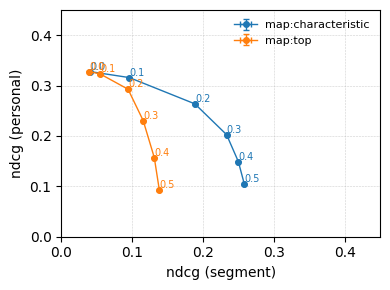

In [34]:
plot(data={"map:characteristic": res, "map:top": res2}, metric_x="ndcg (segment)", metric_y="ndcg (personal)", path="results/figures/njfanfankfna.png")

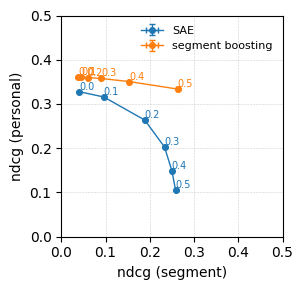

In [30]:
plot(data={"SAE": res, "segment boosting": res3}, metric_x="ndcg (segment)", metric_y="ndcg (personal)", path="results/figures/njfanfankfn3.png")